In [1]:
import pandas as pd

In [6]:
df = pd.read_excel("2023kbo타격기록.xlsx")
df

/tmp/ipython-input-1665665862.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.b = pd.read_excel("2023kbo타격기록.xlsx")


,순위,팀명,AVG,G,PA,AB,R,H,2B,3B,HR,TB,RBI,SAC,SF
0,1,LG,0.279,144,5687,4881,767,1364,227,27,93,1924,714,94,55
1,2,KIA,0.276,144,5607,4954,726,1365,224,21,101,1934,673,63,44
2,3,NC,0.270,144,5606,4895,679,1321,223,28,98,1894,642,63,55
3,4,KT,0.265,144,5649,4973,672,1316,235,14,89,1846,621,57,47
4,5,롯데,0.265,144,5576,4871,653,1289,231,19,69,1765,608,75,57
5,6,삼성,0.263,144,5581,4912,636,1290,208,23,88,1808,603,77,43
6,7,키움,0.261,144,5729,5062,607,1323,223,30,61,1789,576,51,58
7,8,SSG,0.260,144,5630,4923,658,1279,229,16,125,1915,611,77,45
8,9,두산,0.255,144,5538,4859,620,1238,210,32,100,1812,565,57,41
9,10,한화,0.241,144,5628,4906,604,1184,211,12,100,1719,568,59,40


In [7]:
df.w = pd.read_excel("2023kbo팀별승률.xlsx")
df.w

/tmp/ipython-input-850110725.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.w = pd.read_excel("2023kbo팀별승률.xlsx")


,순위,팀명,승률
0,1,LG,0.606
1,2,KT,0.560
2,3,SSG,0.539
3,4,NC,0.528
4,5,두산,0.521
5,6,KIA,0.514
6,7,롯데,0.472
7,8,삼성,0.427
8,9,한화,0.420
9,10,키움,0.411


In [8]:
df["SLG"] = (
    (df["H"] - df["2B"] - df["3B"] - df["HR"])
    + 2*df["2B"]
    + 3*df["3B"]
    + 4*df["HR"]
) / df["AB"]

In [9]:
df["SLG"]

,SLG
0,0.394182
1,0.390392
2,0.386925
3,0.371205
4,0.362349
5,0.368078
6,0.353418
7,0.388990
8,0.372916
9,0.350387


In [ ]:
df["OBP"] = (df["H"] + df["BB"]) / (df["AB"] + df["BB"])

In [16]:
#장타율  구하기
df.b["SLG"] = (
    (df.b["H"] - df.b["2B"] - df.b["3B"] - df.b["HR"])
    + 2*df.b["2B"]
    + 3*df.b["3B"]
    + 4*df.b["HR"]
) / df.b["AB"]

In [17]:
df.b["SLG"]

,SLG
0,0.394182
1,0.390392
2,0.386925
3,0.371205
4,0.362349
5,0.368078
6,0.353418
7,0.388990
8,0.372916
9,0.350387


In [28]:
#ops와 승률의 상관관계
df.b["OPS"].corr(df.w["승률"])

np.float64(0.6995321659008645)

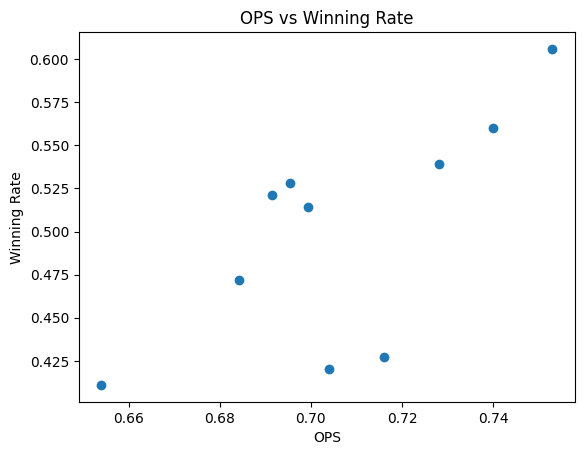

In [35]:
import matplotlib.pyplot as plt

plt.scatter(df.b["OPS"], df.w["승률"])
plt.xlabel("OPS")
plt.ylabel("Winning Rate")
plt.title("OPS vs Winning Rate")
plt.show()

In [36]:
df.b["SLG"].corr(df.w["승률"]) #장타율과 승률의 상관관계

np.float64(0.5300033883138239)

In [37]:
df.b["OBP"].corr(df.w["승률"]) #출루율과 승률의 상관관계

np.float64(0.7934332736234422)

In [38]:
df.b["R"].corr(df.w["승률"]) #득점과 승률의 상관관계 즉, 득점은 승률에 중요한 요소이고 득점을 하기위해서는 출루가 필요함

np.float64(0.841525499284562)

In [40]:
#회귀계수 구하기(통제된 환경 제시)
from sklearn.linear_model import LinearRegression

X = df.b[["OBP", "SLG"]]
y = df.w["승률"]

model = LinearRegression()
model.fit(X, y)

print(model.coef_)

[ 4.13909526 -0.82945435]


In [67]:
df = pd.read_excel("2025팀별타격기록.xlsx")
df

,순위,팀명,AVG,G,PA,AB,R,H,2B,3B,HR,TB,RBI,SAC,SF,BB
0,1,LG,0.278,144,5713,4919,788,1366,219,19,130,2013,732,63,59,604
1,2,삼성,0.271,144,5671,4899,775,1330,241,18,161,2090,728,67,55,564
2,3,롯데,0.267,144,5682,4944,676,1318,242,26,75,1837,629,72,45,530
3,4,한화,0.266,144,5547,4892,689,1303,250,16,116,1933,643,79,46,439
4,5,두산,0.262,144,5581,4952,647,1298,232,31,102,1898,592,53,42,469
5,6,NC,0.260,144,5570,4816,732,1254,221,31,128,1921,685,62,52,504
6,7,KIA,0.258,144,5619,4944,668,1276,232,16,144,1972,624,43,39,526
7,8,SSG,0.256,144,5517,4875,609,1249,175,14,127,1833,578,52,37,493
8,9,KT,0.253,144,5588,4845,648,1228,214,17,104,1788,613,65,43,555
9,10,키움,0.244,144,5508,4935,581,1202,217,20,104,1771,540,38,33,439


In [68]:
df["SLG"]=(
    (df["H"] -df["2B"] - df["3B"] - df["HR"])
    +2*df["2B"]
    +3*df["3B"]
    +4*df["HR"]
) / df["AB"]


In [69]:
df["SLG"]

,SLG
0,0.409230
1,0.426618
2,0.371561
3,0.395135
4,0.383279
5,0.398879
6,0.398867
7,0.376000
8,0.369040
9,0.358865


In [70]:
df["OBP"]=(df["H"] + df["BB"])/(df["AB"] + df["BB"])

In [71]:
df["OBP"]

,OBP
0,0.356690
1,0.346696
2,0.337596
3,0.326768
4,0.325955
5,0.330451
6,0.329433
7,0.324516
8,0.330185
9,0.305359


In [72]:
df["OPS"]=df["SLG"] + df["OBP"]

In [73]:
df["OPS"]

,OPS
0,0.765920
1,0.773314
2,0.709157
3,0.721903
4,0.709234
5,0.729330
6,0.728301
7,0.700516
8,0.699225
9,0.664224


In [74]:
df.w = pd.read_excel("2025팀별승률.xlsx")
df.w

/tmp/ipython-input-3137812656.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.w = pd.read_excel("2025팀별승률.xlsx")


,순위,팀명,승률
0,1,LG,0.603
1,2,한화,0.593
2,3,SSG,0.536
3,4,삼성,0.521
4,5,NC,0.514
5,6,KT,0.511
6,7,롯데,0.478
7,8,KIA,0.464
8,9,두산,0.442
9,10,키움,0.336


In [76]:
df["OPS"].corr(df.w["승률"])

np.float64(0.9067412983087166)

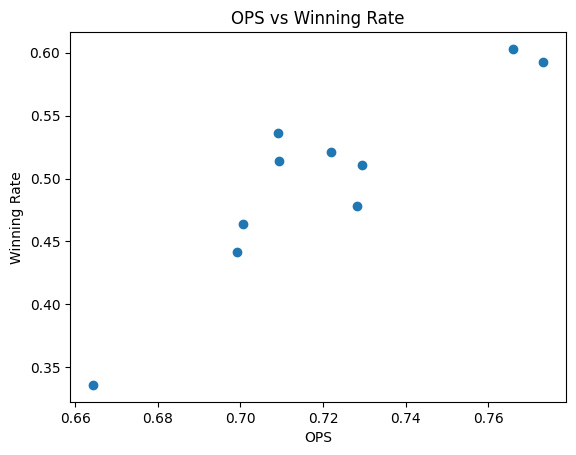

In [77]:
import matplotlib.pyplot as plt

plt.scatter(df["OPS"], df.w["승률"])
plt.xlabel("OPS")
plt.ylabel("Winning Rate")
plt.title("OPS vs Winning Rate")
plt.show()

In [78]:
df["OBP"].corr(df.w["승률"])

np.float64(0.9147889310056452)

In [79]:
df["SLG"].corr(df.w["승률"])

np.float64(0.7978215083258688)

In [80]:
x=df[["OBP","SLG"]]
y=df.w["승률"]

model=LinearRegression()
model.fit(x,y)

print(model.coef_)

[3.97300793 1.06153405]
